Import de dataset y librerias

In [2]:
import pandas as pd
import numpy as np
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skforecast.model_selection import grid_search_forecaster

dataset = 'Lorca_processed.csv'
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure', 'pressure_sensor','month', 'day', 'hour', 'minute']


Dividimos en train y test

In [3]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size]   
data_test  = data.iloc[train_size:]   

Obtenemos los parámetros óptimos

In [ ]:
'''parametros = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 9],
    'n_estimators': [200, 900],
    'subsample': [0.6, 0.8, 1.0]
}

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(), 
    lags = 7
)

cv = TimeSeriesFold(
    initial_train_size = int(len(data_train) * 0.05),
    steps = 366,
    gap = 0
)

grid_search = grid_search_forecaster(
    forecaster = forecaster,
    y = data_train['Power_gen'],
    exog = data_train[exogenas],
    param_grid = parametros,
    cv=cv,
    metric = 'mean_absolute_error',
    return_best = True,
    verbose = False
)'''

Evolucion de las variables exogenas

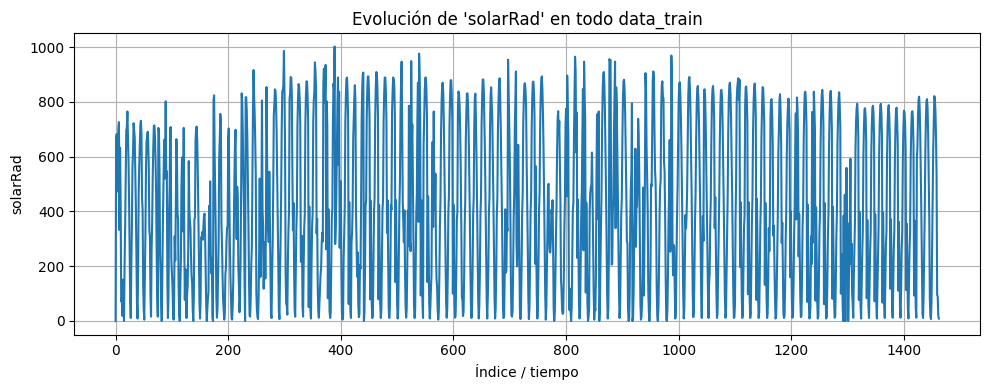

In [4]:
var = "solarRad"  #variable a analizar

plt.figure(figsize=(10, 4))
plt.plot(data_train.index, data_train[var])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en todo data_train")
plt.grid(True)
plt.tight_layout()
plt.show()


Valor de las exogenas para un dia en concreto

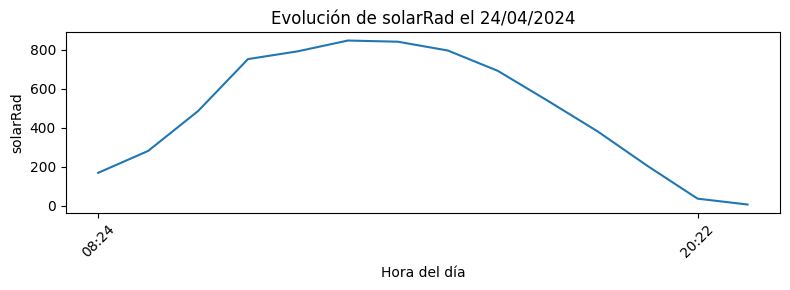

In [5]:
var  = 'solarRad'        #variable exógena a graficar
fecha = "24/04/2024"        
dia = pd.to_datetime(fecha, dayfirst=True)

mask = (
    (data_train["month"] == dia.month) &
    (data_train["day"]   == dia.day)
)
data_dia = data_train.loc[mask].copy()

data_dia["time_str"] = data_dia["hour"].astype(str).str.zfill(2) + ":" + \
                       data_dia["minute"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(data_dia["time_str"], data_dia[var])
ax.set_title(f"Evolución de {var} el {fecha}")
ax.set_xlabel("Hora del día")
ax.set_ylabel(var)

step = 12 
ax.set_xticks(data_dia["time_str"].iloc[::step])
ax.set_xticklabels(data_dia["time_str"].iloc[::step], rotation=45)

plt.tight_layout()
plt.show()


El primer paso es crear el forecaster.

In [6]:
forecaster = ForecasterRecursive(
    estimator = XGBRegressor(learning_rate = 0.01, max_depth = 5, n_estimators = 900, subsample = 0.8),
    lags = 3
)

Entrenamos el forecaster

In [7]:
forecaster.fit(y=data_train['Power_gen'], exog=data_train[exogenas])

Obtenemos las variables mas importantes en el forecaster

In [8]:
importancia = forecaster.get_feature_importances()
print(importancia)

            feature  importance
4          solarRad    0.670489
0             lag_1    0.096360
10            month    0.044507
12             hour    0.039333
1             lag_2    0.032227
2             lag_3    0.020624
3       temperature    0.020309
5           humedad    0.016901
13           minute    0.014817
11              day    0.013862
9   pressure_sensor    0.013218
6         windSpeed    0.009298
8          pressure    0.008055
7              rain    0.000000


Usamos SHAP para crear los datos de entrenamiento

In [9]:
x_train, y_train = forecaster.create_train_X_y(
    y=data_train['Power_gen'],
    exog=data_train[exogenas]
)

print(x_train.head()) 
print(y_train.head(3)) 

    lag_1   lag_2   lag_3  temperature  solarRad  humedad  windSpeed  rain  \
3   0.000  11.512   0.000      12.7778     473.0     46.0    24.1402   0.0   
4   8.651   0.000  11.512      14.4444     594.0     41.0    24.1402   0.0   
5  11.375   8.651   0.000      15.1111     701.0     39.0    17.7028   0.0   
6  13.378  11.375   8.651      16.0000     726.0     34.0    17.7028   0.0   
7  13.874  13.378  11.375      15.7778     332.0     34.0    14.4841   0.0   

   pressure  pressure_sensor  month  day  hour  minute  
3    28.580       395.484262    3.0  8.0  10.0    20.0  
4    28.585       394.392969    3.0  8.0  11.0    20.0  
5    28.572       394.329954    3.0  8.0  12.0    24.0  
6    28.557       457.276472    3.0  8.0  13.0    23.0  
7    28.517       392.994877    3.0  8.0  14.0    27.0  
3     8.651
4    11.375
5    13.378
Name: y, dtype: float64


Explainer del SHAP

In [10]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

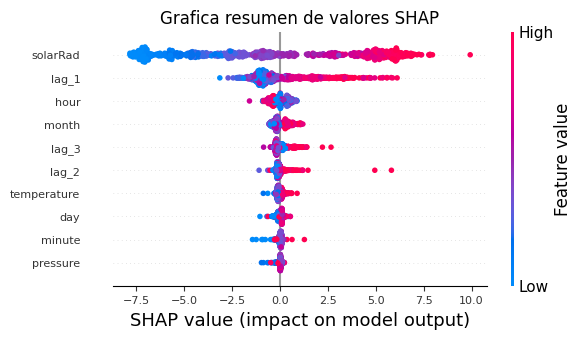

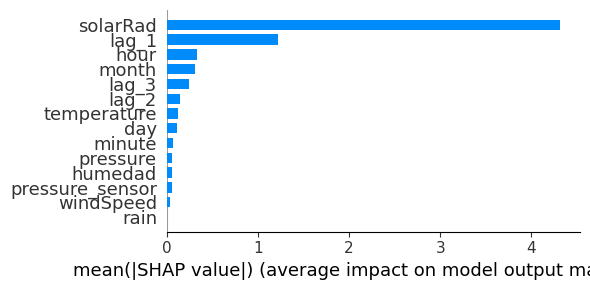

In [11]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(6, 3))
plt.show()

Grafica de dependencia

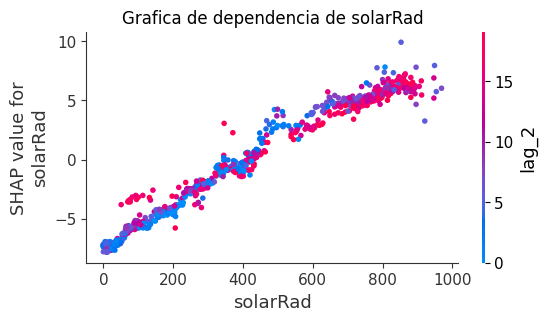

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Ahora veremos las explicaciones de SHAP para predicciones de las proximas 366 muestras (data_test)

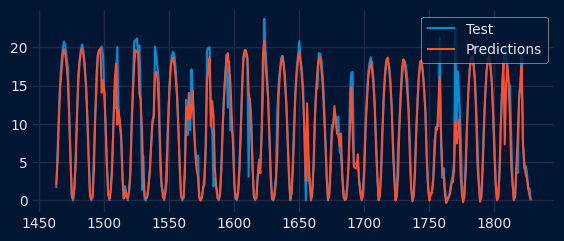

In [13]:
pred = forecaster.predict(steps=366, exog=data_test[exogenas])
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
data_test['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()

Graficas de dependencia parcial.

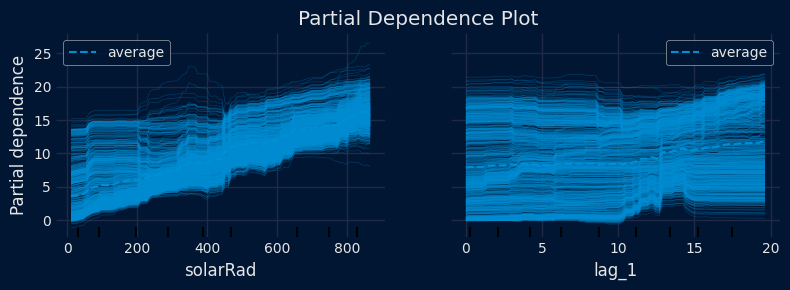

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [15]:
y_test = data_test['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 1.1401
Mean Squared Error (MSE): 4.5251
Root Mean Squared Error (RMSE): 2.1272
Coeficiente de determinación (R^2): 0.9064


Añadimos una variable extra, la irrandiancia ideal, de forma que ayude al modelo a saber hasta que valor podría llegar a ascender.

In [34]:
t_min = data["hour"] * 60 + data["minute"]
t_day = 24 * 60

t_mid = 13 * 60   
x = abs((t_min - t_mid) / (t_day / 2))   

irr_ideal_norm = np.clip(1 - x**2, 0, 1) 

IRR_MAX = 1002 #maxima solarRad en el dataset 
data["irr_ideal"] = IRR_MAX * irr_ideal_norm

In [35]:
exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed',
            'rain', 'pressure', 'pressure_sensor', 'month', 'day', 'hour', 'minute',
            'irr_ideal']

data_train = data.iloc[:train_size].copy()
data_test  = data.iloc[train_size:].copy()

forecaster.fit(y=data_train["Power_gen"],
               exog=data_train[exogenas])

pred = forecaster.predict(steps=len(data_test),
                          exog=data_test[exogenas])

Nuevas métricas de la predicción, ligeramente mejores.

In [36]:
y_test = data_test['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 1.1183
Mean Squared Error (MSE): 4.2504
Root Mean Squared Error (RMSE): 2.0617
Coeficiente de determinación (R^2): 0.9121


Comparativa realidad vs prediccion

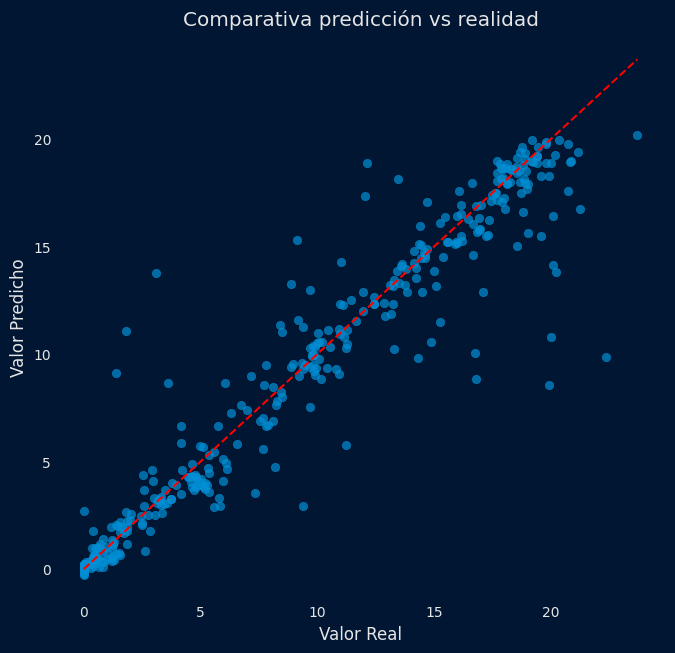

In [37]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()